# Dataset 2 — classification normal / anormal avec distance uniquement

Ce notebook utilise le modèle normal appris dans `dataset0`, puis classe les identifiants de `dataset2` avec la distance robuste.  
On n'utilise plus le pourcentage de fenêtres anormales pour décider normal/anormal.

In [157]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score, f1_score

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

CURRENT_DIR = Path.cwd()

# Compatible si le notebook est lancé depuis ST4/, dataset2/, ou /mnt/data
if CURRENT_DIR.name in ["dataset0", "dataset1", "dataset2", "dataset3", "dataset4"]:
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATASET0_DIR = PROJECT_DIR / "dataset0"
DATASET2_DIR = PROJECT_DIR / "dataset2"

# Fallback utile si les fichiers sont dans le même dossier que le notebook
if not (DATASET2_DIR / "pdfFeatures2.pkl").exists() and (CURRENT_DIR / "pdfFeatures2.pkl").exists():
    DATASET2_DIR = CURRENT_DIR
if not (DATASET0_DIR / "kde_model_dataset0.pkl").exists() and (CURRENT_DIR / "kde_model_dataset0.pkl").exists():
    DATASET0_DIR = CURRENT_DIR

print("CURRENT_DIR  =", CURRENT_DIR)
print("PROJECT_DIR  =", PROJECT_DIR)
print("DATASET0_DIR =", DATASET0_DIR)
print("DATASET2_DIR =", DATASET2_DIR)

CURRENT_DIR  = c:\Users\user\Documents\ST4\dataset2
PROJECT_DIR  = c:\Users\user\Documents\ST4
DATASET0_DIR = c:\Users\user\Documents\ST4\dataset0
DATASET2_DIR = c:\Users\user\Documents\ST4\dataset2


In [158]:
# ============================================================
# Chargement des features dataset 2 et des labels
# ============================================================

FEATURES_PKL_2 = DATASET2_DIR / "pdfFeatures2.pkl"
LABELS_PKL_2 = DATASET2_DIR / "pdfLabel2.pkl"
MODEL_PKL_0 = DATASET0_DIR / "kde_model_dataset0.pkl"

with open(FEATURES_PKL_2, "rb") as f:
    features_2 = pickle.load(f)

with open(LABELS_PKL_2, "rb") as f:
    labels_2 = pickle.load(f)

with open(MODEL_PKL_0, "rb") as f:
    model_artifacts = pickle.load(f)

print("features_2 :", type(features_2), features_2.shape)
print("labels_2   :", type(labels_2), labels_2.shape)
print("Modèle dataset0 chargé :", MODEL_PKL_0)

display(features_2.head())
display(labels_2.head())

features_2 : <class 'pandas.core.frame.DataFrame'> (37369, 275)
labels_2   : <class 'pandas.core.frame.DataFrame'> (150, 2)
Modèle dataset0 chargé : c:\Users\user\Documents\ST4\dataset0\kde_model_dataset0.pkl


C:\Users\user\AppData\Local\Temp\ipykernel_3944\165433871.py:13: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  labels_2 = pickle.load(f)


,e_Absolute energy,e_Area under the curve,e_Autocorrelation,e_Average power,e_Centroid,e_ECDF Percentile Count_0,e_ECDF Percentile Count_1,e_ECDF Percentile_0,e_ECDF Percentile_1,e_ECDF_0,e_ECDF_1,e_ECDF_2,e_ECDF_3,e_ECDF_4,e_ECDF_5,e_ECDF_6,e_ECDF_7,e_ECDF_8,e_ECDF_9,e_Entropy,e_FFT mean coefficient_0,e_FFT mean coefficient_1,e_FFT mean coefficient_2,e_FFT mean coefficient_3,e_FFT mean coefficient_4,e_FFT mean coefficient_5,e_Fundamental frequency,e_Histogram_0,e_Histogram_1,e_Histogram_2,e_Histogram_3,e_Histogram_4,e_Histogram_5,e_Histogram_6,e_Histogram_7,e_Histogram_8,e_Histogram_9,e_Human range energy,e_Interquartile range,e_Kurtosis,...,y_Variance,y_Wavelet absolute mean_0,y_Wavelet absolute mean_1,y_Wavelet absolute mean_2,y_Wavelet absolute mean_3,y_Wavelet absolute mean_4,y_Wavelet absolute mean_5,y_Wavelet absolute mean_6,y_Wavelet absolute mean_7,y_Wavelet absolute mean_8,y_Wavelet energy_0,y_Wavelet energy_1,y_Wavelet energy_2,y_Wavelet energy_3,y_Wavelet energy_4,y_Wavelet energy_5,y_Wavelet energy_6,y_Wavelet energy_7,y_Wavelet energy_8,y_Wavelet entropy,y_Wavelet standard deviation_0,y_Wavelet standard deviation_1,y_Wavelet standard deviation_2,y_Wavelet standard deviation_3,y_Wavelet standard deviation_4,y_Wavelet standard deviation_5,y_Wavelet standard deviation_6,y_Wavelet standard deviation_7,y_Wavelet standard deviation_8,y_Wavelet variance_0,y_Wavelet variance_1,y_Wavelet variance_2,y_Wavelet variance_3,y_Wavelet variance_4,y_Wavelet variance_5,y_Wavelet variance_6,y_Wavelet variance_7,y_Wavelet variance_8,y_Zero crossing rate,i
0,0.059216,0.044443,1.0,0.032898,0.804866,2.0,8.0,-0.088224,0.064545,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.0,0.000083,0.001045,0.000417,0.000711,0.003287,0.007225,0.5,0.0,0.0,0.0,0.0,4.0,6.0,0.0,0.0,0.0,0.0,0.207268,0.104786,-0.956521,...,0.005894,0.003953,0.002323,0.010394,0.01376,0.014741,0.014784,0.014468,0.014021,0.013541,0.036325,0.04878,0.047102,0.040004,0.034969,0.031779,0.029588,0.027927,0.026573,2.17389,0.036109,0.048725,0.045941,0.037563,0.03171,0.028131,0.02581,0.024152,0.022864,0.001304,0.002374,0.002111,0.001411,0.001006,0.000791,0.000666,0.000583,0.000523,7.0,IQVYTIVZI
1,0.044947,0.057335,1.0,0.02497,0.595348,2.0,8.0,-0.068292,0.039978,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.0,0.000333,0.000117,0.002154,0.000433,0.000253,0.002519,0.5,0.0,0.0,0.0,0.0,3.0,7.0,0.0,0.0,0.0,0.0,0.306455,0.066347,-0.323849,...,0.004297,0.011365,0.016926,0.02033,0.022783,0.02369,0.023673,0.023214,0.022566,0.021855,0.053978,0.064548,0.050712,0.040935,0.037197,0.035596,0.034503,0.033496,0.032502,2.16061,0.052768,0.062289,0.046458,0.034009,0.028678,0.026583,0.025526,0.024754,0.024057,0.002784,0.00388,0.002158,0.001157,0.000822,0.000707,0.000652,0.000613,0.000579,5.0,IQVYTIVZI
2,0.043168,0.077023,1.0,0.023982,0.854625,2.0,8.0,-0.068292,0.039978,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.0,0.000284,0.000779,0.003414,0.001659,0.000177,0.000064,1.0,0.0,0.0,0.0,0.0,3.0,7.0,0.0,0.0,0.0,0.0,0.777196,0.06141,-0.73464,...,0.004063,0.002038,0.015738,0.026875,0.031427,0.032646,0.032425,0.031621,0.030606,0.029546,0.080716,0.054223,0.048327,0.048082,0.046963,0.045482,0.043871,0.042252,0.040693,2.171689,0.08069,0.051889,0.040165,0.036389,0.03376,0.031895,0.030411,0.029129,0.027981,0.006511,0.002692,0.001613,0.001324,0.00114,0.001017,0.000925,0.000849,0.000783,3.0,IQVYTIVZI
3,0.0533,0.094651,1.0,0.029611,0.786584,2.0,8.0,-0.098149,0.055082,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.0,0.000009,0.007047,0.000814,0.001104,0.001503,0.00104,0.5,0.0,0.0,0.0,0.0,4.0,6.0,0.0,0.0,0.0,0.0,0.899066,0.096792,-1.037351,...,0.005329,0.001925,0.002131,0.000459,0.001637,0.00206,0.002188,0.0022,0.002164,0.002109,0.067798,0.103941,0.084793,0.06263,0.049234,0.041668,0.037132,0.034135,0.031963,2.115569,0.067771,0.103919,0.084791,0.062608,0.049191,0.041611,0.037067,0.034067,0.031893,0.004593,0.010799,0.00719,0.00392,0.00242,0.001731,0.001374,0.001161,0.001017,3.0,IQVYTIVZI
4,0.067602,0.08591,1.0,0.037556,0.725336,2.0,8.0,-0.1

,d,i
0,0.0,IQVYTIVZI
0,0.0,CFVGY3L1Z
0,0.0,WRJKR0DYH
0,0.0,ZI93DSRKV
0,0.0,NHVHP9SLA


In [159]:
# ============================================================
# Récupération des objets appris sur dataset 0
# ============================================================

feature_columns = model_artifacts["feature_columns"]
feature_medians = model_artifacts["feature_medians"]
scaler = model_artifacts["scaler"]
pca = model_artifacts["pca"]
kde = model_artifacts["kde"]

pca_center_dataset0 = model_artifacts["pca_center_dataset0"]
id_normal_median_dataset0 = model_artifacts["id_normal_median_dataset0"]
id_normal_iqr_dataset0 = model_artifacts["id_normal_iqr_dataset0"]
top_k_distance = model_artifacts.get("top_k_distance", 5)

# On force l'utilisation d'un seuil q95 sur la distance dataset0.
# Si dataset0 a déjà été sauvegardé avec q95, ce sera pareil.
DISTANCE_QUANTILE = 0.97

if "id_kde_pca_stats_dataset0" in model_artifacts:
    seuil_distance_normale_dataset0 = model_artifacts["id_kde_pca_stats_dataset0"]["distance_normale_robuste"].quantile(DISTANCE_QUANTILE)
else:
    seuil_distance_normale_dataset0 = model_artifacts["seuil_distance_normale_dataset0"]

# Très important : on enlève complètement pct_windows_anormales des variables de décision.
id_score_columns = [
    c for c in model_artifacts["id_score_columns"]
    if c != "pct_windows_anormales"
]

print("Nombre de features fenêtres utilisées :", len(feature_columns))
print("Colonnes de distance utilisées par ID :", len(id_score_columns))
print("top_k_distance =", top_k_distance)
print("Quantile distance utilisé =", DISTANCE_QUANTILE)
print("Seuil distance normale dataset0 =", seuil_distance_normale_dataset0)
print("Colonnes utilisées pour la distance :")
print(id_score_columns)

Nombre de features fenêtres utilisées : 246
Colonnes de distance utilisées par ID : 20
top_k_distance = 3
Quantile distance utilisé = 0.97
Seuil distance normale dataset0 = 1412930.502308909
Colonnes utilisées pour la distance :
['kde_anomaly_mean', 'kde_anomaly_std', 'kde_anomaly_median', 'kde_anomaly_max', 'kde_anomaly_q75', 'kde_anomaly_q90', 'kde_anomaly_q95', 'kde_log_density_mean', 'kde_log_density_min', 'kde_log_density_q05', 'pca_dist_mean', 'pca_dist_std', 'pca_dist_max', 'pca_dist_q75', 'pca_dist_q90', 'pca_dist_q95', 'PCA1_std', 'PCA2_std', 'PCA1_range', 'PCA2_range']


In [160]:
# ============================================================
# Nettoyage dataset 2 exactement comme dataset 0
# ============================================================

df_dataset2 = features_2.copy()

X_dataset2 = df_dataset2.drop(columns=["i"], errors="ignore")
X_dataset2 = X_dataset2.apply(pd.to_numeric, errors="coerce")
X_dataset2 = X_dataset2.replace([np.inf, -np.inf], np.nan)

# Même colonnes, même ordre que dataset0
X_dataset2 = X_dataset2.reindex(columns=feature_columns)

# Même imputation que dataset0
X_dataset2 = X_dataset2.fillna(feature_medians)

# Sécurité valeurs infinies
X_dataset2 = X_dataset2.replace([np.inf, -np.inf], np.nan).fillna(feature_medians).fillna(0)

print("Shape dataset2 après alignement :", X_dataset2.shape)
print("NaN restants :", int(X_dataset2.isna().sum().sum()))
print("Inf restants :", int(np.isinf(X_dataset2.to_numpy()).sum()))

Shape dataset2 après alignement : (37369, 246)
NaN restants : 0
Inf restants : 0


In [138]:
# ============================================================
# Projection dans l'espace normal appris sur dataset 0
# ============================================================

X_dataset2_scaled = scaler.transform(X_dataset2)

# Sécurité numérique après scaling
finite_values = X_dataset2_scaled[np.isfinite(X_dataset2_scaled)]
max_finite = np.max(finite_values) if finite_values.size > 0 else 0
min_finite = np.min(finite_values) if finite_values.size > 0 else 0

X_dataset2_scaled = np.nan_to_num(
    X_dataset2_scaled,
    nan=0.0,
    posinf=max_finite,
    neginf=min_finite,
)

X_dataset2_pca = pca.transform(X_dataset2_scaled)
kde_score_dataset2 = kde.score_samples(X_dataset2_pca)

# Score d'anomalie : grand = suspect
kde_anomaly_score_dataset2 = -kde_score_dataset2

# Distance de chaque fenêtre au centre PCA normal
pca_dist_center_dataset2 = np.sqrt(
    (X_dataset2_pca[:, 0] - pca_center_dataset0[0])**2
    + (X_dataset2_pca[:, 1] - pca_center_dataset0[1])**2
)

df_dataset2_result = df_dataset2.copy()
df_dataset2_result["PCA1"] = X_dataset2_pca[:, 0]
df_dataset2_result["PCA2"] = X_dataset2_pca[:, 1]
df_dataset2_result["kde_score"] = kde_score_dataset2
df_dataset2_result["kde_anomaly_score"] = kde_anomaly_score_dataset2
df_dataset2_result["pca_dist_center"] = pca_dist_center_dataset2

print("Projection PCA + score KDE terminés")
print("Nombre de fenêtres dataset2 :", len(df_dataset2_result))
display(df_dataset2_result[["i", "PCA1", "PCA2", "kde_score", "kde_anomaly_score", "pca_dist_center"]].head())

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_data.py:1767: RuntimeWarning: overflow encountered in divide
  X /= self.scale_
C:\Users\user\AppData\Local\Temp\ipykernel_3944\1492354979.py:27: RuntimeWarning: overflow encountered in square
  (X_dataset2_pca[:, 0] - pca_center_dataset0[0])**2
C:\Users\user\AppData\Local\Temp\ipykernel_3944\1492354979.py:28: RuntimeWarning: overflow encountered in square
  + (X_dataset2_pca[:, 1] - pca_center_dataset0[1])**2


Projection PCA + score KDE terminés
Nombre de fenêtres dataset2 : 37369


,i,PCA1,PCA2,kde_score,kde_anomaly_score,pca_dist_center
0,IQVYTIVZI,-56.304880,-9.552228,-5.325016,5.325016,0.343975
1,IQVYTIVZI,-56.439280,-9.367329,-5.325350,5.325350,0.391069
2,IQVYTIVZI,-56.262954,-9.346289,-5.323672,5.323672,0.213492
3,IQVYTIVZI,-55.007066,-10.658006,-5.380327,5.380327,1.697078
4,IQVYTIVZI,-55.573601,-9.394846,-5.328285,5.328285,0.483300


In [161]:
# ============================================================
# Agrégation par identifiant — distance only
# Pas de pourcentage de fenêtres anormales ici.
# ============================================================

def q05(x): return np.quantile(x, 0.05)
def q75(x): return np.quantile(x, 0.75)
def q90(x): return np.quantile(x, 0.90)
def q95(x): return np.quantile(x, 0.95)

summary_dataset2 = (
    df_dataset2_result
    .groupby("i")
    .agg(
        nb_windows=("kde_anomaly_score", "size"),

        # Propriétés KDE : grand = suspect
        kde_anomaly_mean=("kde_anomaly_score", "mean"),
        kde_anomaly_std=("kde_anomaly_score", "std"),
        kde_anomaly_median=("kde_anomaly_score", "median"),
        kde_anomaly_max=("kde_anomaly_score", "max"),
        kde_anomaly_q75=("kde_anomaly_score", q75),
        kde_anomaly_q90=("kde_anomaly_score", q90),
        kde_anomaly_q95=("kde_anomaly_score", q95),

        # Log-density brute KDE : gardée car utilisée dans les distances dataset0
        kde_log_density_mean=("kde_score", "mean"),
        kde_log_density_min=("kde_score", "min"),
        kde_log_density_q05=("kde_score", q05),

        # Distance PCA au centre normal
        pca_dist_mean=("pca_dist_center", "mean"),
        pca_dist_std=("pca_dist_center", "std"),
        pca_dist_max=("pca_dist_center", "max"),
        pca_dist_q75=("pca_dist_center", q75),
        pca_dist_q90=("pca_dist_center", q90),
        pca_dist_q95=("pca_dist_center", q95),

        # Dispersion PCA de l'identifiant
        PCA1_mean=("PCA1", "mean"),
        PCA2_mean=("PCA2", "mean"),
        PCA1_std=("PCA1", "std"),
        PCA2_std=("PCA2", "std"),
        PCA1_min=("PCA1", "min"),
        PCA1_max=("PCA1", "max"),
        PCA2_min=("PCA2", "min"),
        PCA2_max=("PCA2", "max"),
    )
    .reset_index()
)

summary_dataset2["PCA1_range"] = summary_dataset2["PCA1_max"] - summary_dataset2["PCA1_min"]
summary_dataset2["PCA2_range"] = summary_dataset2["PCA2_max"] - summary_dataset2["PCA2_min"]

summary_dataset2 = summary_dataset2.replace([np.inf, -np.inf], np.nan).fillna(0)

print("Résumé par ID :", summary_dataset2.shape)
display(summary_dataset2.head())

Résumé par ID : (150, 28)


,i,nb_windows,kde_anomaly_mean,kde_anomaly_std,kde_anomaly_median,kde_anomaly_max,kde_anomaly_q75,kde_anomaly_q90,kde_anomaly_q95,kde_log_density_mean,kde_log_density_min,kde_log_density_q05,pca_dist_mean,pca_dist_std,pca_dist_max,pca_dist_q75,pca_dist_q90,pca_dist_q95,PCA1_mean,PCA2_mean,PCA1_std,PCA2_std,PCA1_min,PCA1_max,PCA2_min,PCA2_max,PCA1_range,PCA2_range
0,09CCTG4HU,246,7.222000,4.078440,5.352968,39.350777,6.116072,13.104534,14.354753,-7.222000,-39.350777,-14.354753,72.429093,226.080452,1639.350474,6.685230,176.944137,493.652490,9.744103,1.720008,212.238226,82.859134,-57.934326,1512.721591,-485.158565,409.615354,1570.655917,894.773919
1,0PPQTRJTH,332,7.626441,11.448903,5.343589,201.802894,5.745560,12.124576,14.836175,-7.626441,-201.802894,-14.836175,81.321139,346.647108,3927.567563,4.774431,137.069011,381.584558,18.455182,2.548044,325.513572,123.000029,-57.773711,3648.159772,-1314.926783,979.242502,3705.933483,2294.169285
2,165ENWMP7,335,9.208572,32.485013,5.348084,559.714952,5.771723,11.937993,13.848291,-9.208572,-559.714952,-13.848291,74.737522,344.108024,3997.675477,4.924206,92.248730,342.813877,12.244762,1.635625,322.422879,123.521523,-57.809853,3713.725451,-1339.806483,1018.659537,3771.535304,2358.466021
3,1DACI9FCQ,182,7.117603,2.761105,5.427509,16.915842,9.140877,11.542204,12.535633,-7.117603,-16.915842,-12.535633,29.323884,65.614302,369.330112,18.575406,99.773501,178.211124,-30.539625,-0.350514,60.574789,27.663065,-57.677730,312.664658,-120.876194,112.711571,370.342387,233.587765
4,1LYD2X31T,287,6.651353,3.931001,5.345251,38.059639,5.399837,10.667762,14.553933,-6.651353,-38.059639,-14.553933,64.688265,274.880671,2676.296544,1.999441,56.053603,329.526215,2.898428,0.091435,258.013563,98.038292,-57.889583,2472.851893,-885.226986,673.745250,2530.741475,1558.972237


In [162]:
# ============================================================
# Calcul des distances robustes par rapport au normal dataset0
# ============================================================

# Vérification que toutes les colonnes existent
missing_cols = [c for c in id_score_columns if c not in summary_dataset2.columns]
if missing_cols:
    raise ValueError(f"Colonnes absentes dans summary_dataset2 : {missing_cols}")

X_id_2 = summary_dataset2[id_score_columns].copy()

# Distance robuste propriété par propriété : |valeur - médiane normale| / IQR normal
robust_distances_2 = (
    (X_id_2 - id_normal_median_dataset0.reindex(id_score_columns))
    / id_normal_iqr_dataset0.reindex(id_score_columns)
).abs()

robust_distances_2 = robust_distances_2.replace([np.inf, -np.inf], np.nan).fillna(0)

# On garde les distances individuelles pour comprendre pourquoi un ID est suspect
for col in id_score_columns:
    summary_dataset2[f"dist_{col}"] = robust_distances_2[col].values

# Score global : moyenne des top_k plus grandes distances
summary_dataset2["distance_normale_robuste"] = robust_distances_2.apply(
    lambda row: row.nlargest(top_k_distance).mean(),
    axis=1,
)

# Prédiction distance-only
summary_dataset2["prediction_anormal"] = (
    summary_dataset2["distance_normale_robuste"] > seuil_distance_normale_dataset0
).astype(int)

summary_dataset2["classe_predite"] = np.where(
    summary_dataset2["prediction_anormal"] == 1,
    "anormal",
    "normal",
)

print("Répartition prédite :")
print(summary_dataset2["classe_predite"].value_counts())

display(
    summary_dataset2[["i", "distance_normale_robuste", "classe_predite"]]
    .sort_values("distance_normale_robuste", ascending=False)
    .head(20)
)

Répartition prédite :
classe_predite
normal     103
anormal     47
Name: count, dtype: int64


,i,distance_normale_robuste,classe_predite
148,ZOXCH5OEH,2.132295e+304,anormal
118,SYRAKGYPD,5.454005e+07,anormal
26,6AUUAM8S2,3.039354e+07,anormal
97,M3Z92ZCQS,1.766323e+07,anormal
110,QUB2ZELAS,1.441746e+07,anormal
93,LPMZA5MZ8,1.295931e+07,anormal
88,L8XNECEZQ,1.243227e+07,anormal
2,165ENWMP7,1.132008e+07,anormal
70,G2XKX4KBG,8.244660e+06,anormal
92,LGEGCYMBV,7.970041e+06,anormal


In [163]:
# ============================================================
# Ajout des vrais labels dataset2
# defaut 0 = normal ; autre défaut = anormal
# ============================================================

labels_2 = labels_2.copy()

# Nom de colonne label. Normalement c'est "d".
if "d" in labels_2.columns:
    label_col = "d"
else:
    candidates = [c for c in labels_2.columns if c != "i"]
    if len(candidates) != 1:
        raise ValueError(f"Impossible de trouver la colonne label. Colonnes disponibles : {labels_2.columns.tolist()}")
    label_col = candidates[0]

labels_2["is_anormal_true"] = (labels_2[label_col] != 0).astype(int)

summary_dataset2 = summary_dataset2.merge(
    labels_2[["i", label_col, "is_anormal_true"]],
    on="i",
    how="left",
)

print("Colonne label utilisée :", label_col)
print("Labels vrais :")
print(summary_dataset2["is_anormal_true"].value_counts(dropna=False))
print("Labels manquants :", int(summary_dataset2["is_anormal_true"].isna().sum()))

display(summary_dataset2[["i", label_col, "is_anormal_true", "distance_normale_robuste", "classe_predite"]].head())

Colonne label utilisée : d
Labels vrais :
is_anormal_true
0    90
1    60
Name: count, dtype: int64
Labels manquants : 0


,i,d,is_anormal_true,distance_normale_robuste,classe_predite
0,09CCTG4HU,0.0,0,4.935494e+05,normal
1,0PPQTRJTH,0.0,0,3.873475e+06,anormal
2,165ENWMP7,0.0,0,1.132008e+07,anormal
3,1DACI9FCQ,4.0,1,2.677989e+04,normal
4,1LYD2X31T,0.0,0,4.666863e+05,normal


Matrice de confusion :
[[61 29]
 [42 18]]
Lignes = vrais labels ; colonnes = prédictions
[[vrai normal prédit normal, vrai normal prédit anormal],
 [vrai anormal prédit normal, vrai anormal prédit anormal]]
Scores :
Accuracy          : 0.5267
Balanced accuracy : 0.4889
F1 anormal        : 0.3364
Rapport détaillé :
              precision    recall  f1-score   support

      normal       0.59      0.68      0.63        90
     anormal       0.38      0.30      0.34        60

    accuracy                           0.53       150
   macro avg       0.49      0.49      0.48       150
weighted avg       0.51      0.53      0.51       150



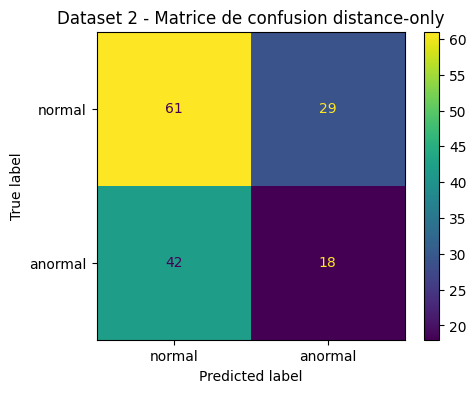

In [164]:
# ============================================================
# Matrice de confusion et qualité des résultats
# ============================================================

eval_df = summary_dataset2.dropna(subset=["is_anormal_true"]).copy()

y_true = eval_df["is_anormal_true"].astype(int).to_numpy()
y_pred = eval_df["prediction_anormal"].astype(int).to_numpy()

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

print("Matrice de confusion :")
print(cm)
print("Lignes = vrais labels ; colonnes = prédictions")
print("[[vrai normal prédit normal, vrai normal prédit anormal],")
print(" [vrai anormal prédit normal, vrai anormal prédit anormal]]")

print("Scores :")
print("Accuracy          :", round(accuracy_score(y_true, y_pred), 4))
print("Balanced accuracy :", round(balanced_accuracy_score(y_true, y_pred), 4))
print("F1 anormal        :", round(f1_score(y_true, y_pred), 4))

print("Rapport détaillé :")
print(classification_report(y_true, y_pred, target_names=["normal", "anormal"]))

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["normal", "anormal"])
disp.plot(ax=ax, values_format="d")
plt.title("Dataset 2 - Matrice de confusion distance-only")
plt.grid(False)
plt.show()

In [165]:
# ============================================================
# Analyse des erreurs
# ============================================================

eval_df["type_resultat"] = np.select(
    [
        (eval_df["is_anormal_true"] == 0) & (eval_df["prediction_anormal"] == 0),
        (eval_df["is_anormal_true"] == 0) & (eval_df["prediction_anormal"] == 1),
        (eval_df["is_anormal_true"] == 1) & (eval_df["prediction_anormal"] == 0),
        (eval_df["is_anormal_true"] == 1) & (eval_df["prediction_anormal"] == 1),
    ],
    ["TN_normal_bien_classe", "FP_normal_classe_anormal", "FN_anormal_rate", "TP_anormal_bien_classe"],
    default="inconnu",
)

print("Types de résultats :")
print(eval_df["type_resultat"].value_counts())

# Les erreurs les plus importantes à inspecter
cols_view = [
    "i", label_col, "is_anormal_true", "prediction_anormal", "classe_predite",
    "type_resultat", "distance_normale_robuste",
    "kde_anomaly_mean", "kde_anomaly_q90", "kde_anomaly_q95", "kde_anomaly_max",
    "pca_dist_mean", "pca_dist_q90", "pca_dist_q95", "PCA1_range", "PCA2_range",
]

print("Faux négatifs : anormaux ratés")
display(eval_df[eval_df["type_resultat"] == "FN_anormal_rate"][cols_view].sort_values("distance_normale_robuste"))

print("Faux positifs : normaux classés anormaux")
display(eval_df[eval_df["type_resultat"] == "FP_normal_classe_anormal"][cols_view].sort_values("distance_normale_robuste", ascending=False))

Types de résultats :
type_resultat
TN_normal_bien_classe       61
FN_anormal_rate             42
FP_normal_classe_anormal    29
TP_anormal_bien_classe      18
Name: count, dtype: int64
Faux négatifs : anormaux ratés


,i,d,is_anormal_true,prediction_anormal,classe_predite,type_resultat,distance_normale_robuste,kde_anomaly_mean,kde_anomaly_q90,kde_anomaly_q95,kde_anomaly_max,pca_dist_mean,pca_dist_q90,pca_dist_q95,PCA1_range,PCA2_range
126,UC4M32NLW,5.0,1,0,normal,FN_anormal_rate,6.907096e+03,6.314161,9.826950,11.905597,15.960878,14.085448,25.246679,67.886516,693.987470,351.700288
137,X1M0U42CL,4.0,1,0,normal,FN_anormal_rate,2.139153e+04,6.563929,10.665422,11.466590,16.657028,14.910190,51.513613,88.457886,332.492329,137.788055
3,1DACI9FCQ,4.0,1,0,normal,FN_anormal_rate,2.677989e+04,7.117603,11.542204,12.535633,16.915842,29.323884,99.773501,178.211124,370.342387,233.587765
103,NHC4522FP,5.0,1,0,normal,FN_anormal_rate,3.177897e+04,6.728743,11.248070,12.562642,17.156286,19.294866,45.552847,99.225379,423.556127,226.116775
111,QXRN1DJ3S,4.0,1,0,normal,FN_anormal_rate,4.399247e+04,7.698346,11.852424,12.801870,17.742398,38.239998,119.825834,192.346133,505.126082,292.446477
143,YA0FNQ33D,4.0,1,0,normal,FN_anormal_rate,4.945142e+04,7.549287,12.349532,12.976008,18.005292,48.753350,155.672376,261.171336,980.971084,505.125614
20,4U2ZB99XF,5.0,1,0,normal,FN_anormal_rate,5.670290e+04,7.269506,12.758964,15.959287,18.354137,49.372487,101.200027,282.157590,1046.824580,512.476726
14,3JOJRSXPO,4.0,1,0,normal,FN_anormal_rate,5.943646e+04,6.810201,11.126929,11.907914,18.485558,21.378968,67.048624,132.330737,361.490752,197.788954
47,AAY6WXHL3,4.0,1,0,normal,FN_anormal_rate,8.954301e+04,7.072019,11.284202,12.405396,19.932510,29.733286,77.454490,159.049135,847.968249,335.026121
5,1ZJHC20K3,5.0,1,0,normal,FN_anormal_rate,9.029127e+04,7.033010,11.890630,14.010990,19.968561,32.289999,60.620428,156.872233,1049.150764,563.274051


Faux positifs : normaux classés anormaux


,i,d,is_anormal_true,prediction_anormal,classe_predite,type_resultat,distance_normale_robuste,kde_anomaly_mean,kde_anomaly_q90,kde_anomaly_q95,kde_anomaly_max,pca_dist_mean,pca_dist_q90,pca_dist_q95,PCA1_range,PCA2_range
148,ZOXCH5OEH,0.0,0,1,anormal,FP_normal_classe_anormal,2.132295e+304,0.000000,11.710451,13.691628,0.000000,0.000000,81.364113,200.715430,3.101908e+307,3.950014e+307
88,L8XNECEZQ,0.0,0,1,anormal,FP_normal_classe_anormal,1.243227e+07,8.179484,10.807702,12.743697,613.170959,43.998410,50.847668,189.611402,3.647844e+03,1.750942e+03
2,165ENWMP7,0.0,0,1,anormal,FP_normal_classe_anormal,1.132008e+07,9.208572,11.937993,13.848291,559.714952,74.737522,92.248730,342.813877,3.771535e+03,2.358466e+03
76,I4ZQEMPTZ,0.0,0,1,anormal,FP_normal_classe_anormal,7.928501e+06,8.596234,13.420821,15.649971,396.702825,105.680835,225.039566,621.545949,4.206027e+03,1.999101e+03
18,4MNYYWAW3,0.0,0,1,anormal,FP_normal_classe_anormal,7.573044e+06,7.911900,11.666261,13.745104,379.618233,58.471177,81.844657,255.639012,3.103760e+03,1.522660e+03
89,LBU6LJA0G,0.0,0,1,anormal,FP_normal_classe_anormal,7.445713e+06,8.397919,12.956990,15.145820,373.498201,97.529216,183.051013,617.213936,3.534602e+03,1.892277e+03
71,GJQYSC88J,0.0,0,1,anormal,FP_normal_classe_anormal,6.005424e+06,7.521994,12.030273,14.190836,304.272520,60.282756,118.849857,353.553417,3.302300e+03,1.891145e+03
62,DOSYZLP62,0.0,0,1,anormal,FP_normal_classe_anormal,5.517235e+06,8.574539,13.651350,15.521354,280.808153,116.562561,282.072302,668.723490,4.608445e+03,2.214695e+03
9,33BVWEG0J,0.0,0,1,anormal,FP_normal_classe_anormal,5.233257e+06,7.664450,11.466551,14.158073,267.159175,58.998021,71.796588,279.568482,3.087250e+03,1.473848e+03
79,IQVYTIVZI,0.0,0,1,anormal,FP_normal_classe_anormal,4.801561e+06,7.988882,11.765510,14.670004,246.410138,68.458521,116.249047,277.402574,2.860079e+03,1.746812e+03


In [166]:
# ============================================================
# Quelles propriétés expliquent le plus la distance ?
# ============================================================

dist_cols = [f"dist_{c}" for c in id_score_columns]

# Pour chaque ID, on récupère les top distances qui ont le plus contribué
TOP_EXPLAIN = min(top_k_distance, len(dist_cols))

def top_distance_names(row):
    vals = row[dist_cols].sort_values(ascending=False).head(TOP_EXPLAIN)
    return ", ".join([f"{name.replace('dist_', '')}={value:.2f}" for name, value in vals.items()])

summary_dataset2["principales_distances"] = summary_dataset2.apply(top_distance_names, axis=1)

display(
    summary_dataset2[["i", "classe_predite", "distance_normale_robuste", "principales_distances"]]
    .sort_values("distance_normale_robuste", ascending=False)
    .head(30)
)

,i,classe_predite,distance_normale_robuste,principales_distances
148,ZOXCH5OEH,anormal,2.132295e+304,PCA2_range=44642405296112799195829886037555729...
118,SYRAKGYPD,anormal,5.454005e+07,"kde_anomaly_max=81809915.16, kde_log_density_m..."
26,6AUUAM8S2,anormal,3.039354e+07,"kde_anomaly_max=45590219.80, kde_log_density_m..."
97,M3Z92ZCQS,anormal,1.766323e+07,"kde_anomaly_max=26494763.05, kde_log_density_m..."
110,QUB2ZELAS,anormal,1.441746e+07,"kde_anomaly_max=21626142.65, kde_log_density_m..."
93,LPMZA5MZ8,anormal,1.295931e+07,"kde_anomaly_max=19438918.25, kde_log_density_m..."
88,L8XNECEZQ,anormal,1.243227e+07,"kde_log_density_min=18648371.34, kde_anomaly_m..."
2,165ENWMP7,anormal,1.132008e+07,"kde_anomaly_max=16980091.30, kde_log_density_m..."
70,G2XKX4KBG,anormal,8.244660e+06,"kde_anomaly_max=12366962.45, kde_log_density_m..."
92,LGEGCYMBV,anormal,7.970041e+06,"kde_anomaly_max=11955040.10, kde_log_density_m..."


In [167]:
# ============================================================
# Sauvegarde des résultats
# ============================================================

output_pkl = DATASET2_DIR / "summary_detection_dataset2_distance_only.pkl"
output_csv = DATASET2_DIR / "summary_detection_dataset2_distance_only.csv"

summary_dataset2.to_pickle(output_pkl)
summary_dataset2.to_csv(output_csv, index=False)

print("Résultats sauvegardés :")
print(output_pkl)
print(output_csv)

Résultats sauvegardés :
c:\Users\user\Documents\ST4\dataset2\summary_detection_dataset2_distance_only.pkl
c:\Users\user\Documents\ST4\dataset2\summary_detection_dataset2_distance_only.csv
